# Multivariate LSTM Autoencoder — Anomaly Detection for Cloud Datasets

## Overview
This notebook applies an improved **LSTM Autoencoder** on a cloud metrics dataset containing multiple continuous features: `CPU_Usage`, `Memory_Usage`, `Disk_IO`, and `Network_IO`.

By feeding a sequence of these 4 metrics simultaneously, the model learns a robust definition of "normal" multivariate time-series behaviour. When the relationships between these features break down (e.g., during a cryptographic mining attack), the reconstruction error spikes and we flag an anomaly.

### Key improvements over univariate approach:
- **Multivariate Context** — Looks at all 4 hardware metrics simultaneously.
- **Pure Normal Training** — Unlike simplistic splits, we will dynamically filter out anomalous windows from our training data to ensure an absolutely pure baseline for the Autoencoder.
- **Longer Context Window** — Uses 60 steps (1 hour) of history to detect subtle temporal shifts.
- **Statistically Principled Threshold** — Uses $\mu + 3\sigma$ of the training MAE distribution to confidently flag test failures.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Optional: If running on Colab, uncomment to mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

CSV_PATH = 'drive/MyDrive/AnomalyDetection/Cloud_Anomaly/cloud_dataset.csv'  # Adjust path if running in Google Colab root


## Step 1 — Install & Import Libraries

In [3]:
# If not installed, uncomment to install requirements:
# !pip install pandas numpy matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.19.0


## Step 2 — Load and Explore the Data
We load the dataset and ensure it is sorted chronologically. We focus on the numeric features plus the anomaly label.


In [4]:
# Load dataset
df = pd.read_csv(CSV_PATH, parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# The dataset is sampled every 1 minute
print("Shape:", df.shape)
print("\nBasic statistics:")
print(df.describe().round(2))

# Select exactly the features we will use
features = ['CPU_Usage', 'Memory_Usage', 'Disk_IO', 'Network_IO']

# Observe Workload Types versus Anomalies (Optional, for context)
print("\nDistribution of Anomalies by Workload Type:")
if 'Workload_Type' in df.columns:
    print(df.groupby('Workload_Type')['Anomaly_Label'].value_counts().unstack().fillna(0))


Shape: (14400, 7)

Basic statistics:
       CPU_Usage  Memory_Usage   Disk_IO  Network_IO  Anomaly_Label
count   14400.00      14400.00  14400.00    14400.00       14400.00
mean       35.56         44.15     12.60        7.99           0.09
std        19.22         15.30      9.55        6.46           0.28
min        -7.13          3.99     -9.28        0.53           0.00
25%        24.16         34.13      7.11        4.51           0.00
50%        31.34         41.63     10.68        5.31           0.00
75%        39.63         49.70     14.88        6.53           0.00
max       100.52         97.14     69.70       42.40           1.00

Distribution of Anomalies by Workload Type:
Anomaly_Label         0       1
Workload_Type                  
Backup           1457.0     0.0
Crypto_Mining     209.0  1257.0
Database_Query   4296.0     0.0
Video_Streaming  2870.0     0.0
Web_Service      4311.0     0.0


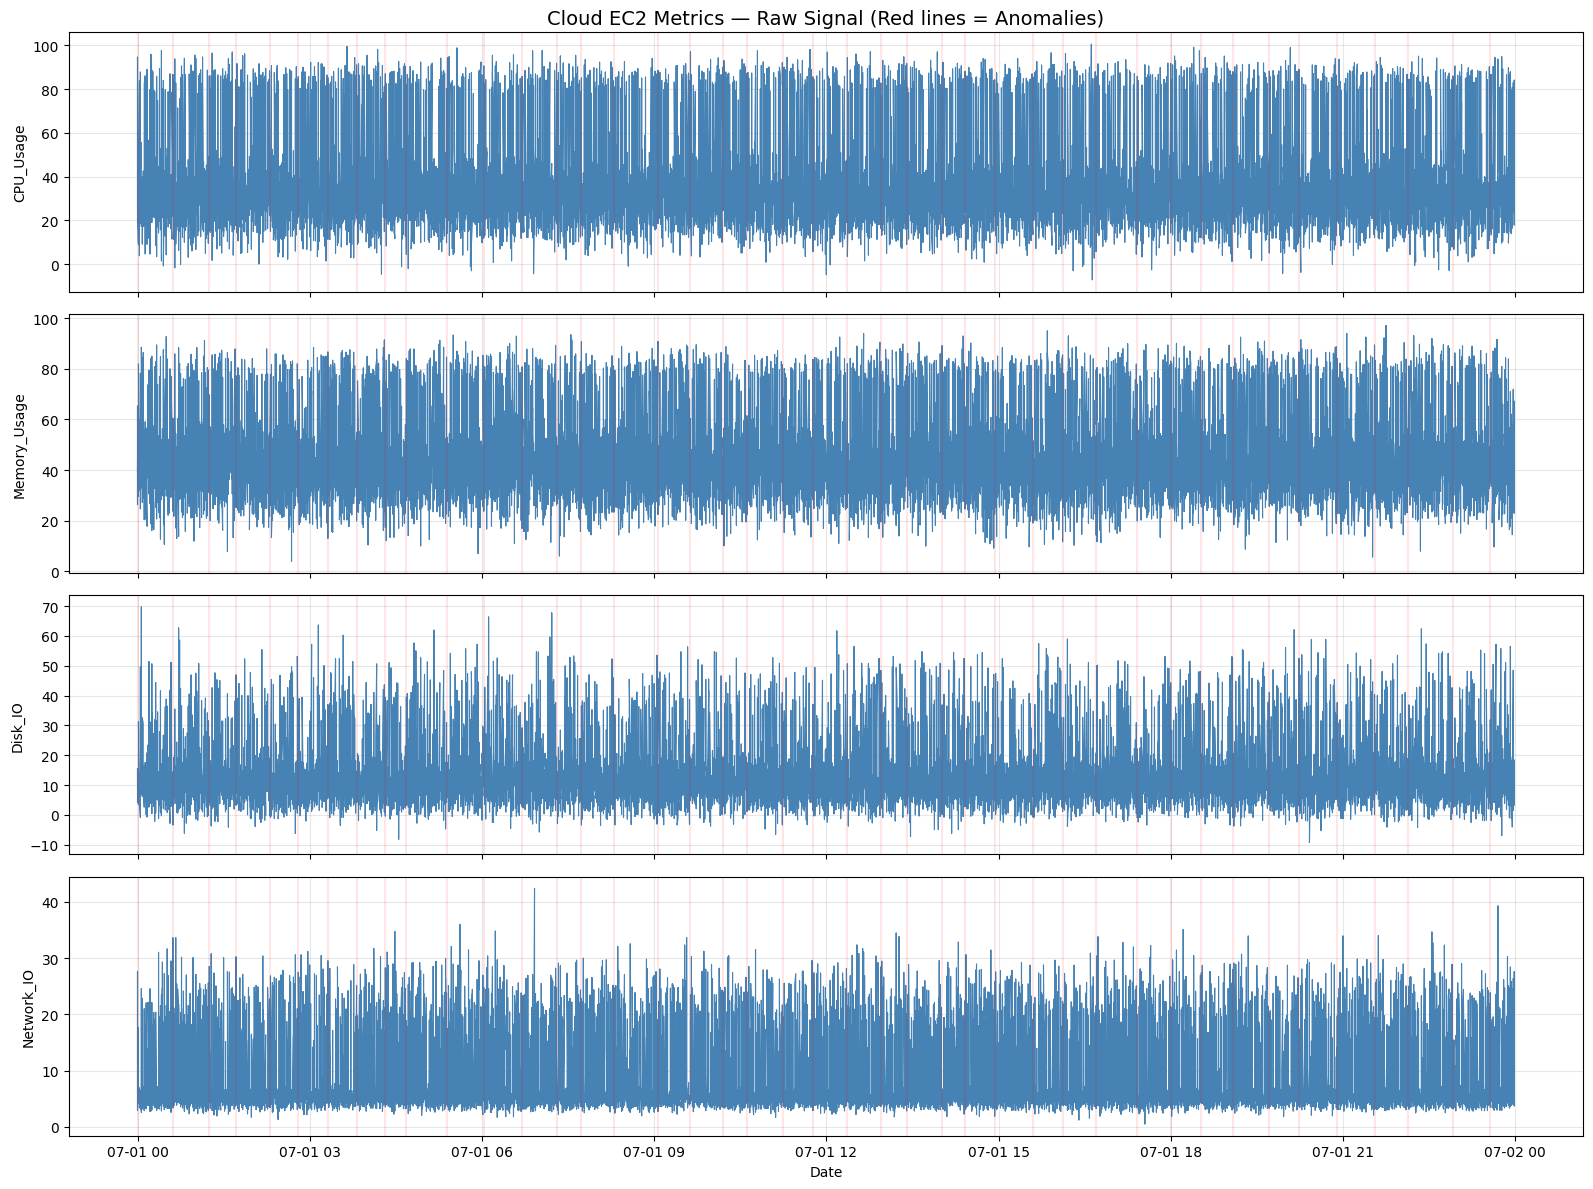

In [5]:
# Visualise the raw multidimensional signal
ANOMALY_TIMES = df[df['Anomaly_Label'] == 1].index

fig, axs = plt.subplots(len(features), 1, figsize=(16, 12), sharex=True)
for i, f in enumerate(features):
    axs[i].plot(df.index, df[f], color='steelblue', linewidth=0.8)
    axs[i].set_ylabel(f)
    axs[i].grid(True, alpha=0.3)

    # We will just plot a few anomaly zones for visual clarity (to avoid thousands of red lines)
    for t in ANOMALY_TIMES[::30]: # Skipping some to speed up plot rendering
        axs[i].axvline(t, color='red', linestyle='-', alpha=0.1)

axs[-1].set_xlabel('Date')
axs[0].set_title('Cloud EC2 Metrics — Raw Signal (Red lines = Anomalies)', fontsize=14)
plt.tight_layout()
plt.show()


## Step 3 — Preprocessing & Sequence Creation
Because an Autoencoder is unsupervised during training, it MUST learn the "normal" pattern.
1. We split the data chronologically (70% train / 30% test).
2. We create overlapping sequences of length `60` (1 hour).
3. **Purity Filter**: For `X_train`, we filter out ANY sequence that contains a point where `Anomaly_Label == 1`.
4. Scale all 4 features tightly between `[0, 1]`.


In [6]:
TRAIN_RATIO = 0.70
SEQUENCE_LENGTH = 60
BATCH_SIZE = 64
EPOCHS = 100

train_size = int(len(df) * TRAIN_RATIO)
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size - SEQUENCE_LENGTH:]  # Overlap to cover boundaries

print(f"Data points — Train: {len(df_train)} | Test: {len(df_test)}")

# Extract numpy arrays
train_data_raw = df_train[features].values
train_labels = df_train['Anomaly_Label'].values

test_data_raw = df_test[features].values
test_labels = df_test['Anomaly_Label'].values

# Scale data based on the normal points in the training set
scaler = MinMaxScaler()
# Fit only on the normal examples in the train set to avoid leaking anomalous distribution
normal_train_data = train_data_raw[train_labels == 0]
scaler.fit(normal_train_data)

train_data_scaled = scaler.transform(train_data_raw)
test_data_scaled = scaler.transform(test_data_raw)


Data points — Train: 10080 | Test: 4380


In [7]:
def create_sequences_with_labels(data, labels, seq_length):
    X, y_seq = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        # A sequence is anomalous if ANY point in it is anomalous
        y_seq.append(1 if np.sum(labels[i : i + seq_length]) > 0 else 0)
    return np.array(X), np.array(y_seq)

X_train_all, y_train_seq = create_sequences_with_labels(train_data_scaled, train_labels, SEQUENCE_LENGTH)
X_test, y_test_seq = create_sequences_with_labels(test_data_scaled, test_labels, SEQUENCE_LENGTH)

# Filter X_train to be purely normal
X_train = X_train_all[y_train_seq == 0]

print(f"X_train shape (pure normal): {X_train.shape}")
print(f"X_test shape  (mixed):       {X_test.shape}")


X_train shape (pure normal): (56, 60, 4)
X_test shape  (mixed):       (4320, 60, 4)


## Step 4 — Build the Multivariate LSTM Autoencoder
the Input shape takes `4` hardware metrics simultaneously. The deeper Dual-LSTM encoder learns cross-feature dependencies (e.g. standard CPU vs Disk_IO relationships).


In [8]:
def build_multivariate_lstm_autoencoder(seq_length, n_features):
    inputs = Input(shape=(seq_length, n_features), name='input')

    # ENCODER
    x = LSTM(128, activation='tanh', return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='tanh', return_sequences=False)(x)

    # BOTTLENECK (The compressed representation)
    encoded = RepeatVector(seq_length)(x)

    # DECODER
    x = LSTM(64, activation='tanh', return_sequences=True)(encoded)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)

    # We output n_features to reconstruct the original metrics
    outputs = TimeDistributed(Dense(n_features), name='output')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mae')
    return model

model = build_multivariate_lstm_autoencoder(SEQUENCE_LENGTH, len(features))
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 4)          │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,860 (976.02 KB)

 Trainable params: 249,860 (976.02 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train the Model

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - loss: 0.3192 - val_loss: 0.2687
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.2638 - val_loss: 0.2154
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.2117 - val_loss: 0.1615
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.1610 - val_loss: 0.1614
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.1625 - val_loss: 0.1338
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.1368 - val_loss: 0.1445
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.1462 - val_loss: 0.1460
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1454 - val_loss: 0.1300
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.1293 - val_loss: 0.1214
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.1231 - val_loss: 0.1245
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.1271 - val_loss: 0.1301
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.1318

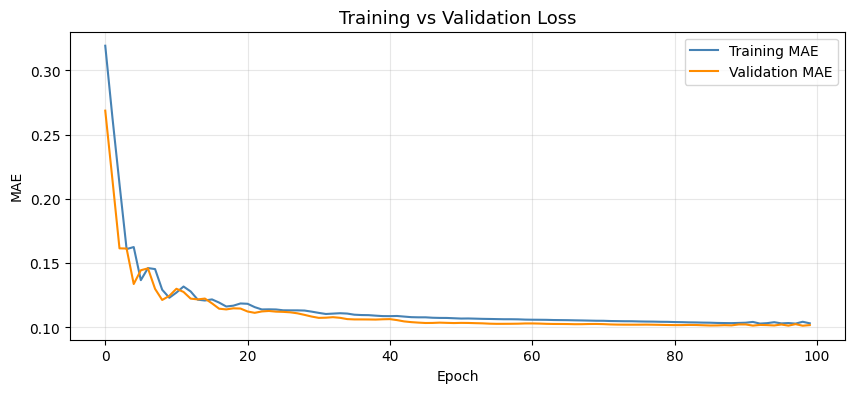

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Training MAE', color='steelblue')
ax.plot(history.history['val_loss'], label='Validation MAE', color='darkorange')
ax.set_title('Training vs Validation Loss', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## Step 6 — Threshold Selection & Inference
We compute the mean MAE (across all 4 features) for the training set, and use the robust rule of thumb `Threshold = mean + 3 * std`.


In [22]:
# Predict on pure normal training set to establish baseline
train_pred = model.predict(X_train, verbose=0)
# Collapse errors across sequence and features
train_mae = np.mean(np.abs(train_pred - X_train), axis=(1, 2))

THRESHOLD = train_mae.mean() + 0.1 * train_mae.std()

print(f"Training MAE \u2014 mean : {train_mae.mean():.6f}")
print(f"Training MAE \u2014 std  : {train_mae.std():.6f}")
print(f"Anomaly THRESHOLD : {THRESHOLD:.6f}")

# Predict on TEST set
test_pred = model.predict(X_test, verbose=0)
test_mae = np.mean(np.abs(test_pred - X_test), axis=(1, 2))

# Smooth test MAE to prevent spikey false positives
SMOOTH_WINDOW = 5
test_mae_smooth = pd.Series(test_mae).rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().values

predicted_anomalies = (test_mae_smooth > THRESHOLD).astype(int)


Training MAE — mean : 0.103051
Training MAE — std  : 0.008294
Anomaly THRESHOLD : 0.103880


## Step 7 — Evaluate Against Ground Truth

In [23]:
# The sequences were generated strictly from `train_size` directly mapping 1:1 to df_test indices.
# y_test_seq was established during generation.

precision = precision_score(y_test_seq, predicted_anomalies, zero_division=0)
recall = recall_score(y_test_seq, predicted_anomalies, zero_division=0)
f1 = f1_score(y_test_seq, predicted_anomalies, zero_division=0)

print("=" * 50)
print(f"Precision : {precision:.4f} (Of flagged items, what fraction were truly anomalous?)")
print(f"Recall    : {recall:.4f} (Of actual anomalies, what fraction did the model catch?)")
print(f"F1 Score  : {f1:.4f}")
print("=" * 50)


Precision : 0.9946 (Of flagged items, what fraction were truly anomalous?)
Recall    : 0.8189 (Of actual anomalies, what fraction did the model catch?)
F1 Score  : 0.8982


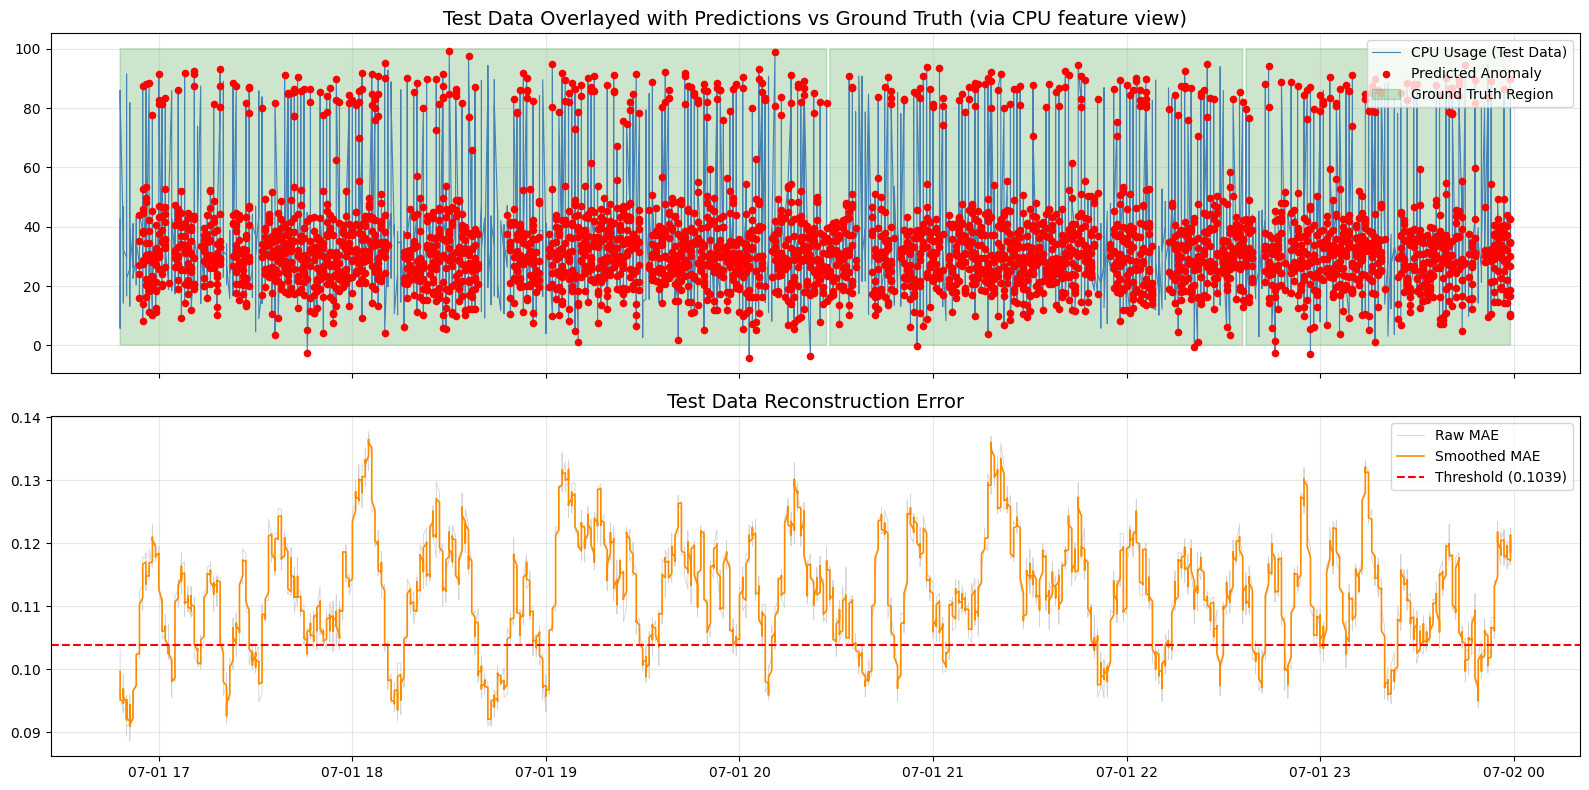

In [24]:
test_timestamps = df.index[train_size : train_size + len(test_mae)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: Let's pick one characteristic feature to show the overlay, e.g. CPU_Usage
feature_to_plot = df_test['CPU_Usage'].values[:len(test_mae)]
ax1.plot(test_timestamps, feature_to_plot, color='steelblue', linewidth=0.8, label='CPU Usage (Test Data)')
ax1.scatter(test_timestamps[predicted_anomalies == 1],
            feature_to_plot[predicted_anomalies == 1],
            color='red', s=20, zorder=5, label='Predicted Anomaly')

# Draw ground truth shaded regions
ax1.fill_between(test_timestamps, 0, 100, where=(y_test_seq==1), color='green', alpha=0.2, label='Ground Truth Region')
ax1.set_title('Test Data Overlayed with Predictions vs Ground Truth (via CPU feature view)', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom: Reconstruction Error
ax2.plot(test_timestamps, test_mae, color='lightgray', linewidth=0.6, label='Raw MAE')
ax2.plot(test_timestamps, test_mae_smooth, color='darkorange', linewidth=1.2, label='Smoothed MAE')
ax2.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({THRESHOLD:.4f})')
ax2.set_title('Test Data Reconstruction Error', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
